In [ ]:
import matplotlib.pyplot as plt
import random
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
import os


In [ ]:
def parse_lfw_pairs(pairs_filepath, img_dir_path):
    """
    Parses the LFW pairs file and generates file paths and labels.
    
    Args:
        pairs_filepath: Path to pairsDevTest.txt
        img_dir_path: Path to the root folder of LFW-a images
        
    Returns:
        pairs: List of tuples (path_img1, path_img2)
        labels: List of integers (1 for same, 0 for different)
    """
    pairs = []
    labels = []
    
    with open(pairs_filepath, 'r') as f:
        lines = f.readlines()
    
    # The first line is the number of pairs (e.g., 500)
    # We can usually skip this variable in the loop logic, 
    # but it's good to know it exists.
    n_folds = int(lines[0]) 
    
    for line in lines[1:]:
        components = line.strip().split()
        
        if len(components) == 3:
            # Case: Same Person (Name, ID1, ID2)
            name = components[0]
            id1 = components[1]
            id2 = components[2]
            
            # Construct paths with zero-padding (zfill)
            # Format: Name/Name_0000.jpg
            img1_path = os.path.join(img_dir_path, name, f"{name}_{id1.zfill(4)}.jpg")
            img2_path = os.path.join(img_dir_path, name, f"{name}_{id2.zfill(4)}.jpg")
            
            pairs.append((img1_path, img2_path))
            labels.append(1)
            
        elif len(components) == 4:
            name1 = components[0]
            id1 = components[1]
            name2 = components[2]
            id2 = components[3]
            
            img1_path = os.path.join(img_dir_path, name1, f"{name1}_{id1.zfill(4)}.jpg")
            img2_path = os.path.join(img_dir_path, name2, f"{name2}_{id2.zfill(4)}.jpg")
            
            pairs.append((img1_path, img2_path))
            labels.append(0)

    return pairs, labels


test_pairs_file = '../data/pairsDevTest.txt'
train_pairs_file = '../data/pairsDevTrain.txt'
img_directory = '../data/lfw2'

test_pairs, test_labels = parse_lfw_pairs(test_pairs_file, img_directory)
train_pairs, train_labels = parse_lfw_pairs(train_pairs_file, img_directory)

In [3]:
def analyze_dataset(pairs, labels, set_name="Train"):
    print(f"\n--- Analysis for {set_name} Set ---")
    
    n_pos = sum(labels)
    n_neg = len(labels) - n_pos
    print(f"Positive Pairs (Same): {n_pos} ({n_pos/len(labels):.1%})")
    print(f"Negative Pairs (Diff): {n_neg} ({n_neg/len(labels):.1%})")
    
    names = set()
    for p1, p2 in pairs:
        name1 = os.path.basename(os.path.dirname(p1))
        name2 = os.path.basename(os.path.dirname(p2))
        names.add(name1)
        names.add(name2)
        
    print(f"Unique People involved: {len(names)}")
    return names

train_names = analyze_dataset(train_pairs, train_labels, "Train")
test_names = analyze_dataset(test_pairs, test_labels, "Test")

overlap = train_names.intersection(test_names)
print(f"\nOverlap between Train and Test people: {len(overlap)}")
if len(overlap) > 0:
    print(f"Warning! Found overlapping names: {list(overlap)[:5]}")
else:
    print("Success: No person appears in both Train and Test sets.")


--- Analysis for Train Set ---
Positive Pairs (Same): 1100 (50.0%)
Negative Pairs (Diff): 1100 (50.0%)
Unique People involved: 2132

--- Analysis for Test Set ---
Positive Pairs (Same): 500 (50.0%)
Negative Pairs (Diff): 500 (50.0%)
Unique People involved: 963

Overlap between Train and Test people: 0
Success: No person appears in both Train and Test sets.


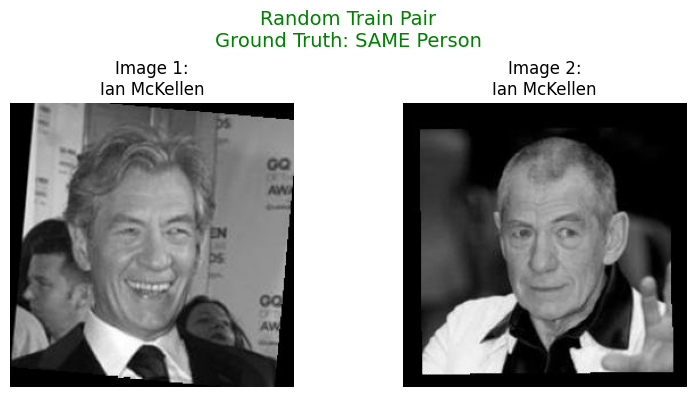

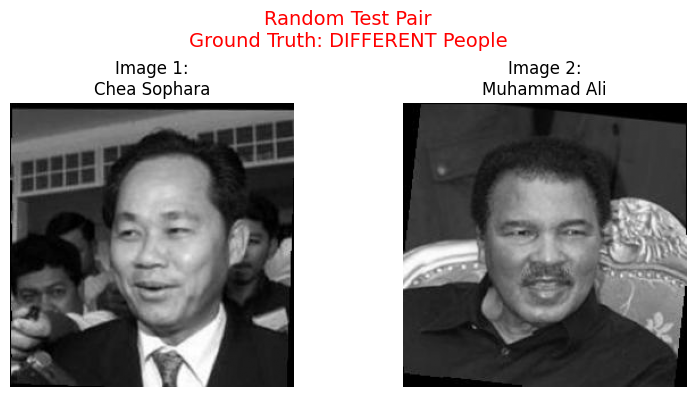

In [19]:
def visualize_sample(pairs, labels, title="Sample Pair",seed=None):
    if seed is not None:
        random.seed(seed)
    idx = random.randint(0, len(pairs)-1)
    img1_path, img2_path = pairs[idx]
    label = labels[idx]
    
    if not os.path.exists(img1_path) or not os.path.exists(img2_path):
        print(f"\nCannot visualize: Images not found at {img1_path}")
        return

    img1 = mpimg.imread(img1_path)
    img2 = mpimg.imread(img2_path)
    image_name1 = os.path.basename(img1_path)
    image_name2 = os.path.basename(img2_path)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img1, cmap='gray')
    ax[0].set_title(f'Image 1:\n{image_name1[:-9].replace('_',' ')}')
    ax[0].axis('off')
    
    ax[1].imshow(img2, cmap='gray')
    ax[1].set_title(f'Image 2:\n{image_name2[:-9].replace('_',' ')}')
    ax[1].axis('off')
    
    label_text = "SAME Person" if label == 1 else "DIFFERENT People"
    color = 'green' if label == 1 else 'red'

    plt.suptitle(f"{title}\nGround Truth: {label_text}", color=color, fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_sample(train_pairs, train_labels, "Random Train Pair",seed=42)
visualize_sample(test_pairs, test_labels, "Random Test Pair",seed=42)

Starting calculation for 2200 pairs...
Stats: Same=1100, Diff=1100


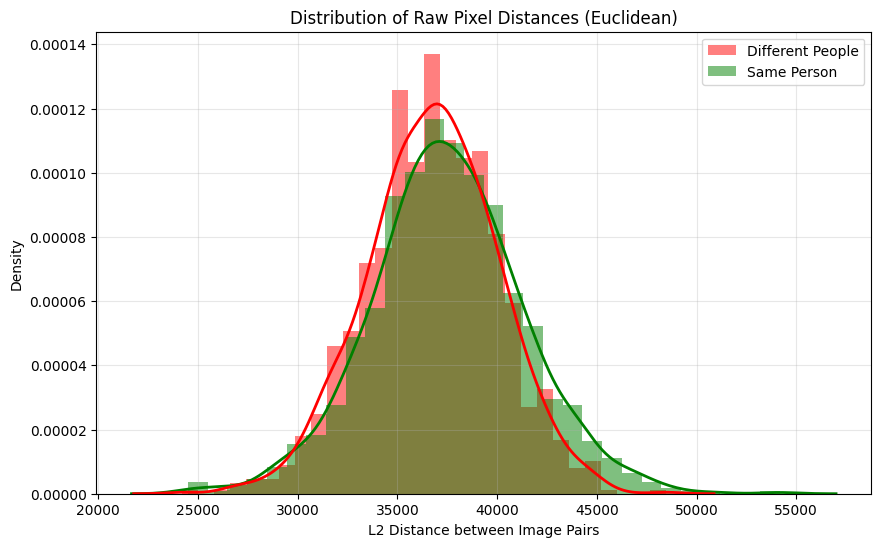

Starting calculation for 1000 pairs...
Stats: Same=500, Diff=500


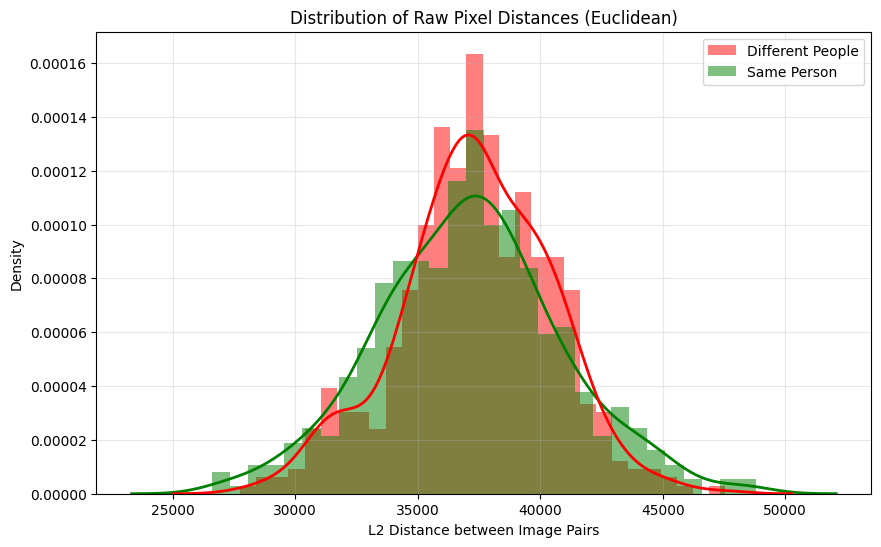

In [20]:
def plot_pixel_distance_distribution(pairs, labels):
    pairs = np.array(pairs)
    labels = np.array(labels)
    
    distances = []
    valid_labels = []
    
    print(f"Starting calculation for {len(pairs)} pairs...")
    
    # 2. Calculate Distances
    for i in range(len(pairs)):
        p1, p2 = pairs[i]

        if not os.path.exists(p1) or not os.path.exists(p2):
            continue
         
        try:
            # Read and flatten
            img1 = mpimg.imread(p1).flatten()
            img2 = mpimg.imread(p2).flatten()
            
            dist = np.linalg.norm(img1 - img2)
            distances.append(dist)
            valid_labels.append(labels[i])
        except Exception as e:
            print(f"Error processing pair {p1}, {p2}: {e}")
            pass

    distances = np.array(distances)
    valid_labels = np.array(valid_labels)


    plt.figure(figsize=(10, 6))
    # Filter using the numpy arrays
    same_person_dists = distances[valid_labels == 1]
    diff_person_dists = distances[valid_labels == 0]
    
    print(f"Stats: Same={len(same_person_dists)}, Diff={len(diff_person_dists)}")

    # Use Matplotlib directly (more robust than Seaborn for this specific error)
    plt.hist(diff_person_dists, bins=30, alpha=0.5, color='red', label='Different People', density=True)
    plt.hist(same_person_dists, bins=30, alpha=0.5, color='green', label='Same Person', density=True)
    
    # Add KDE (Kernel Density Estimate) lines if you have seaborn
    if len(same_person_dists) > 1:
        sns.kdeplot(same_person_dists, color='green', linewidth=2)
    if len(diff_person_dists) > 1:
        sns.kdeplot(diff_person_dists, color='red', linewidth=2)
    
    plt.title("Distribution of Raw Pixel Distances (Euclidean)")
    plt.xlabel("L2 Distance between Image Pairs")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Run the fixed function
plot_pixel_distance_distribution(train_pairs, train_labels)
plot_pixel_distance_distribution(test_pairs, test_labels)

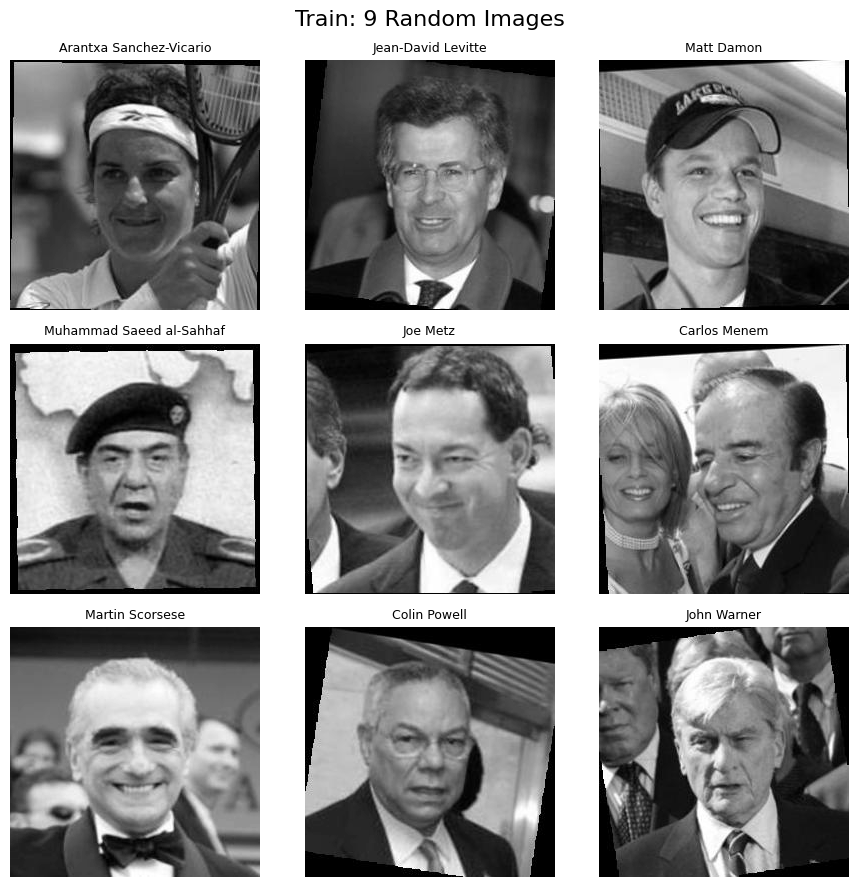

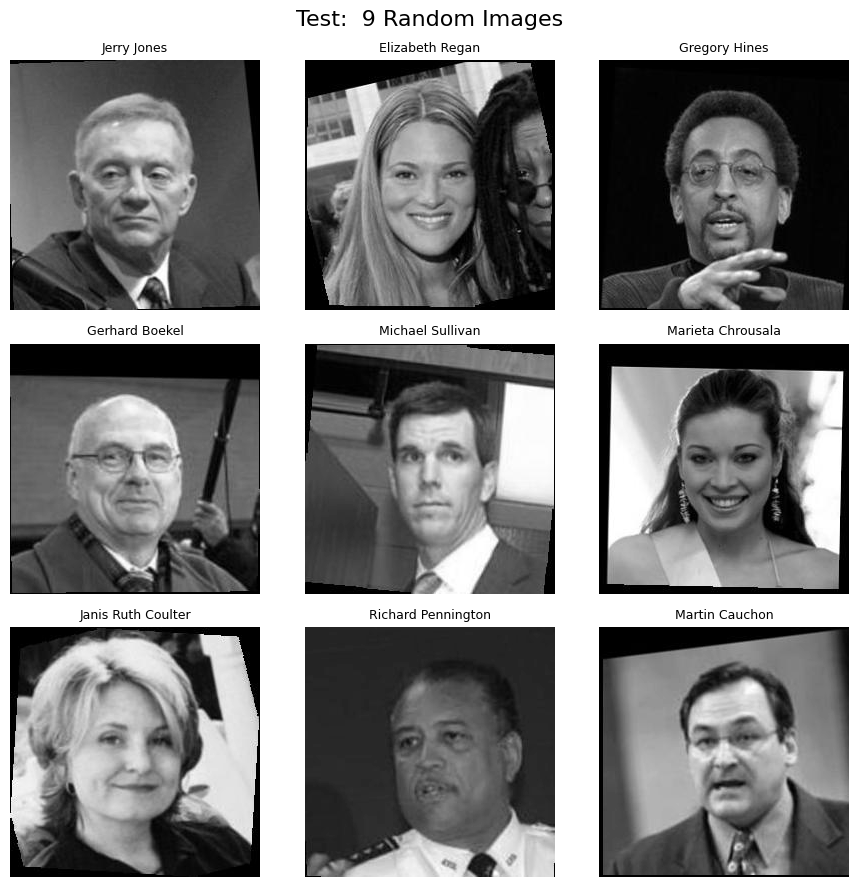

In [ ]:
def show_random_grid_from_pairs(pairs, title, n=9, seed=None):
    imgs = []
    for p1, p2 in pairs:
        imgs.append(p1)
        imgs.append(p2)
    imgs = list(dict.fromkeys(imgs))

    if seed is not None:
        random.seed(seed)
    sample = random.sample(imgs, min(n, len(imgs)))

    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < len(sample) and os.path.exists(sample[i]):
            img = mpimg.imread(sample[i])
            ax.imshow(img, cmap='gray')
            person = os.path.basename(os.path.dirname(sample[i])).replace('_', ' ')
            ax.set_title(person, fontsize=9)
            ax.axis('off')
        else:
            ax.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

show_random_grid_from_pairs(train_pairs, "Train: 9 Random Images")
show_random_grid_from_pairs(test_pairs,  "Test:  9 Random Images") 